# **1. Entedimiento del problema**

El gobierno Australiano quiere conocer cuanto puede ser el costo de el uso de corticoides y esteroides en el sistema de salud actual para preparar sus finanzas a futuro.

# **2. Enfoque Analitico**

Vamos a construir un modelo de regresion basado en series de tiempo que permite estimar el costo de corticoides y esteroides con el menor MAE posible

# **3. Requerimiento de los datos**

Se requieren los datos pasados del costo de los medicamentos

# **4. Recoleccion de datos**

In [1]:
import matplotlib.pyplot as plt
from skforecast.datasets import fetch_dataset

In [2]:
data = fetch_dataset(name = 'h2o_exog')
data.index.name = 'datetime'

╭─────────────────────────────────── h2o_exog ────────────────────────────────────╮
│ Description:                                                                    │
│ Monthly expenditure ($AUD) on corticosteroid drugs that the Australian health   │
│ system had between 1991 and 2008. Two additional variables (exog_1, exog_2) are │
│ simulated.                                                                      │
│                                                                                 │
│ Source:                                                                         │
│ Hyndman R (2023). fpp3: Data for Forecasting: Principles and Practice (3rd      │
│ Edition). http://pkg.robjhyndman.com/fpp3package/,                              │
│ https://github.com/robjhyndman/fpp3package, http://OTexts.com/fpp3.             │
│                                                                                 │
│ URL:                                                                            │
│ https://raw.githubusercontent.com/skforecast/skforecast-                        │
│ datasets/main/data/h2o_exog.csv                                                 │
│                                                                                 │
│ Shape: 195 rows x 3 columns                                                     │
╰─────────────────────────────────────────────────────────────────────────────────╯

In [3]:
data

,y,exog_1,exog_2
datetime,,,
1992-04-01,0.379808,0.958792,1.166029
1992-05-01,0.361801,0.951993,1.117859
1992-06-01,0.410534,0.952955,1.067942
1992-07-01,0.483389,0.958078,1.097376
1992-08-01,0.475463,0.956370,1.122199
...,...,...,...
2008-02-01,0.761822,1.515840,1.786373
2008-03-01,0.649435,1.506258,1.694264
2008-04-01,0.827887,1.505253,1.627135


# **5. Exploracion de datos**

- Identificar los patrones estacionales de la Serie
- Determinar la estacioneridad de la Serie

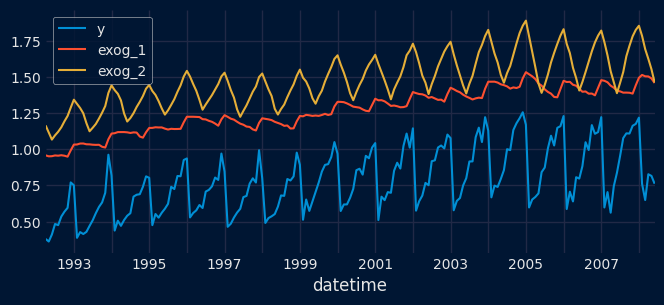

In [4]:
from skforecast.plot import set_dark_theme
set_dark_theme()
# **5. Exploracion de datos**
fig, ax = plt.subplots(figsize=(7, 3))
data.plot(ax=ax)
ax.legend()
plt.show()

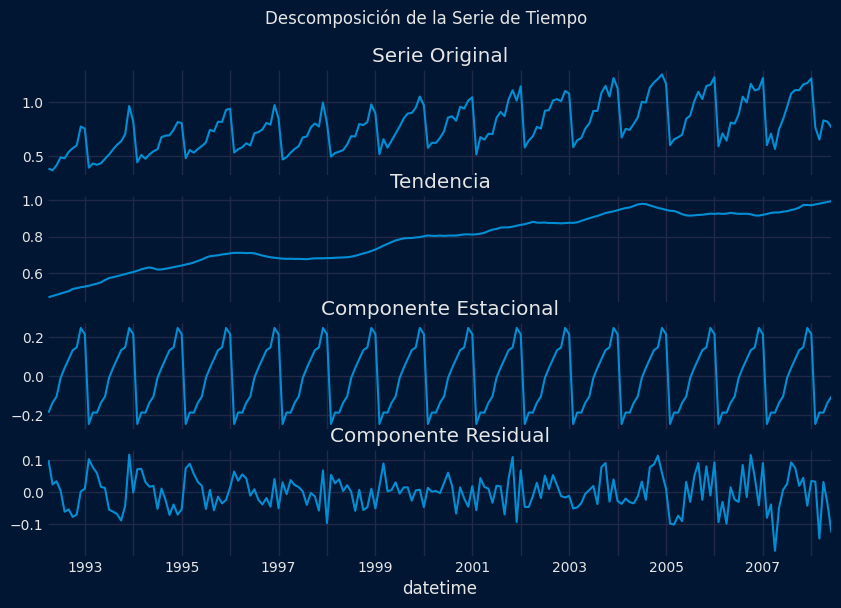

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
res_descompose = seasonal_decompose(data['y'], model='additive', extrapolate_trend='freq')
fig, ax = plt.subplots(4, 1, figsize=(9, 6), sharex=True)
res_descompose.observed.plot(ax=ax[0])
ax[0].set_title('Serie Original')
res_descompose.trend.plot(ax=ax[1])
ax[1].set_title('Tendencia')
res_descompose.seasonal.plot(ax=ax[2])
ax[2].set_title('Componente Estacional')
res_descompose.resid.plot(ax=ax[3])
ax[3].set_title('Componente Residual')
fig.suptitle('Descomposición de la Serie de Tiempo')
plt.show()

In [6]:
#test de Dickey-Fuller
from statsmodels.tsa.stattools import adfuller
print('Test de Estacionariedad de Dickey-Fuller')
adfuller_result = adfuller(data['y'])
print(f'ADF Estadístico: {adfuller_result[0]}, p-value: {adfuller_result[1]}')

Test de Estacionariedad de Dickey-Fuller
ADF Estadístico: -1.5180458060933528, p-value: 0.5245662008648627


Por tanto la serie no es estacionaria.

Tenemos que volver estacionaria la serie

Visualmente cumple con covarianza y varianza constante! Falta que cumpla con la **media constante**

# **6. Preparacion de los datos**

- Diferenciar la serie
- Identificar su comportamiento estacional

Test de Estacionariedad
ADF Estadístico: -3.272501193023007, p-value: 0.01615332013567157


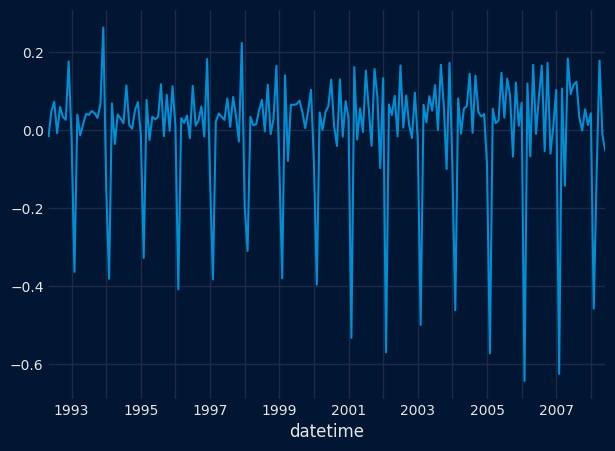

In [7]:
data_diff = data['y'].diff().dropna()
print('Test de Estacionariedad')
adfuller_result = adfuller(data_diff)
print(f'ADF Estadístico: {adfuller_result[0]}, p-value: {adfuller_result[1]}')
data_diff.plot()
plt.show()

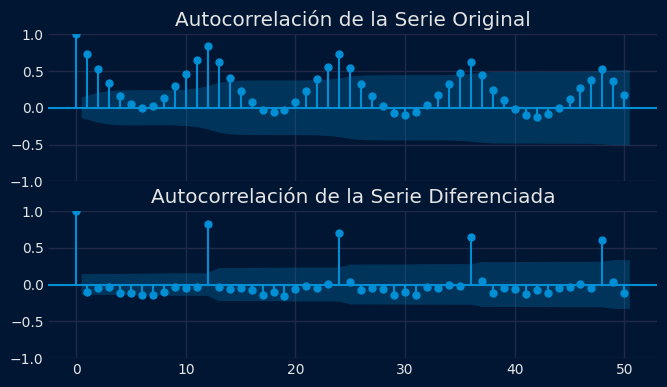

In [8]:
# graficos de correlacion y correlacion parcial
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
#Grafico de autocorrelacion
fig, ax = plt.subplots(2, 1, figsize=(7, 4), sharex=True)
plot_acf(data['y'], ax=ax[0], lags=50, alpha=0.05)
ax[0].set_title('Autocorrelación de la Serie Original')
plot_acf(data_diff, ax=ax[1], lags=50, alpha=0.05)
ax[1].set_title('Autocorrelación de la Serie Diferenciada')
plt.show()

Hay una tendencias en componente estacional ya que va disminuyendo.

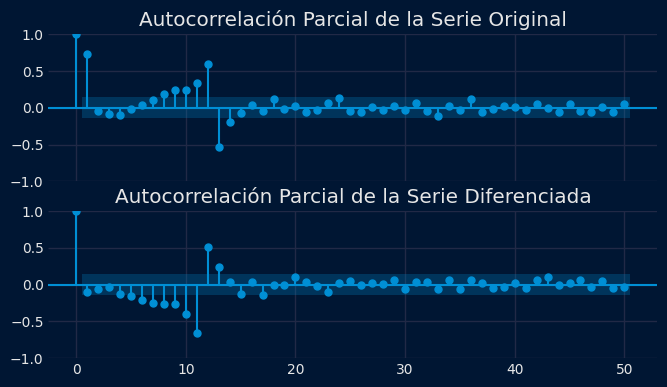

In [9]:
# graficos de correlacion y correlacion parcial
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
#Grafico de autocorrelacion parcial
fig, ax = plt.subplots(2, 1, figsize=(7, 4), sharex=True)
plot_pacf(data['y'], ax=ax[0], lags=50, alpha=0.05)
ax[0].set_title('Autocorrelación Parcial de la Serie Original')
plot_pacf(data_diff, ax=ax[1], lags=50, alpha=0.05)
ax[1].set_title('Autocorrelación Parcial de la Serie Diferenciada')
plt.show()

In [10]:
# Diferenciacion de la serie estacional
data_diff_12 = data['y'].diff().diff(12).dropna()
adfuller_result = adfuller(data_diff_12)
print(f'ADF Statistic: {adfuller_result[0]}, p-value: {adfuller_result[1]}')

ADF Statistic: -5.177607779375993, p-value: 9.766313840443076e-06


<Figure size 700x300 with 0 Axes>

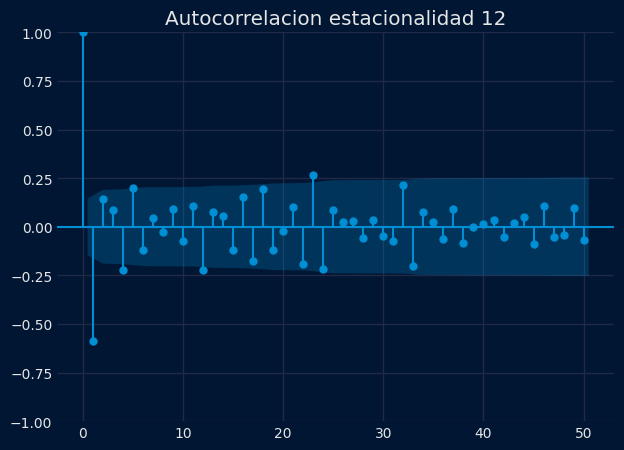

In [11]:
# Grafico de autocorrelacion de la serie estacionaria estacional
plt.figure(figsize=(7,3))
plot_acf(data_diff_12, lags=50, alpha=0.05)
plt.title('Autocorrelacion estacionalidad 12')
plt.show()

Solo un resago sale de las bandas por lo tanto Q -> 1

<Figure size 700x300 with 0 Axes>

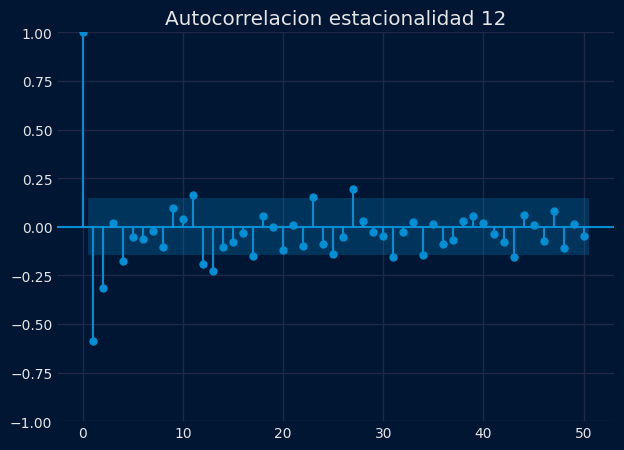

In [12]:
# Grafico de autocorrelacion parcial de la serie
plt.figure(figsize=(7,3))
plot_pacf(data_diff_12, lags=50, alpha=0.05)
plt.title('Autocorrelacion estacionalidad 12')
plt.show()

P -> 2

# Imputacion de nulos en series de tiempo

In [13]:
import statsmodels.api as sm
import pandas as pd
df_serie = sm.datasets.get_rdataset('airquality').data
df_serie['year'] = 1973
df_serie['date'] = pd.to_datetime(df_serie[['year', 'Month', 'Day']])
df_serie.index = df_serie['date']
df_serie.drop(['year', 'Month', 'Day', 'date'], axis=1, inplace=True)
df_serie

,Ozone,Solar.R,Wind,Temp
date,,,,
1973-05-01,41.0,190.0,7.4,67
1973-05-02,36.0,118.0,8.0,72
1973-05-03,12.0,149.0,12.6,74
1973-05-04,18.0,313.0,11.5,62
1973-05-05,NaN,NaN,14.3,56
...,...,...,...,...
1973-09-26,30.0,193.0,6.9,70
1973-09-27,NaN,145.0,13.2,77
1973-09-28,14.0,191.0,14.3,75


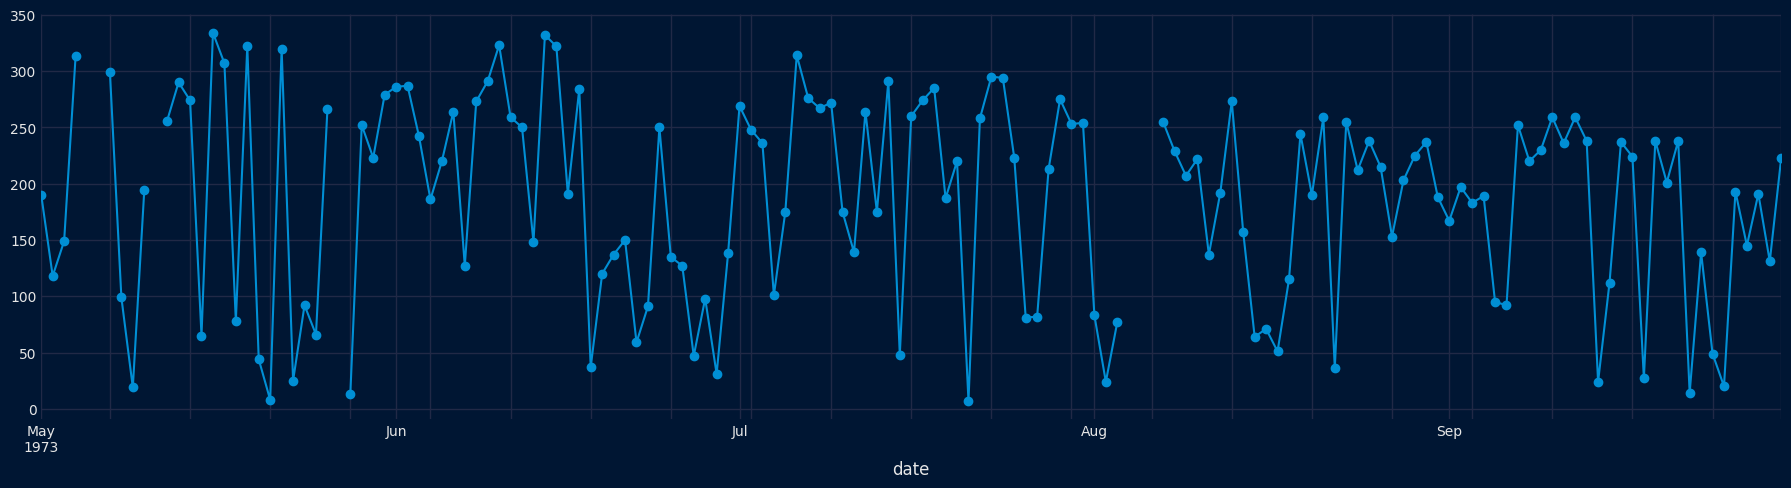

In [14]:
plt.figure(figsize=(20,5))
df_serie['Solar.R'].plot(marker = 'o')
plt.show()

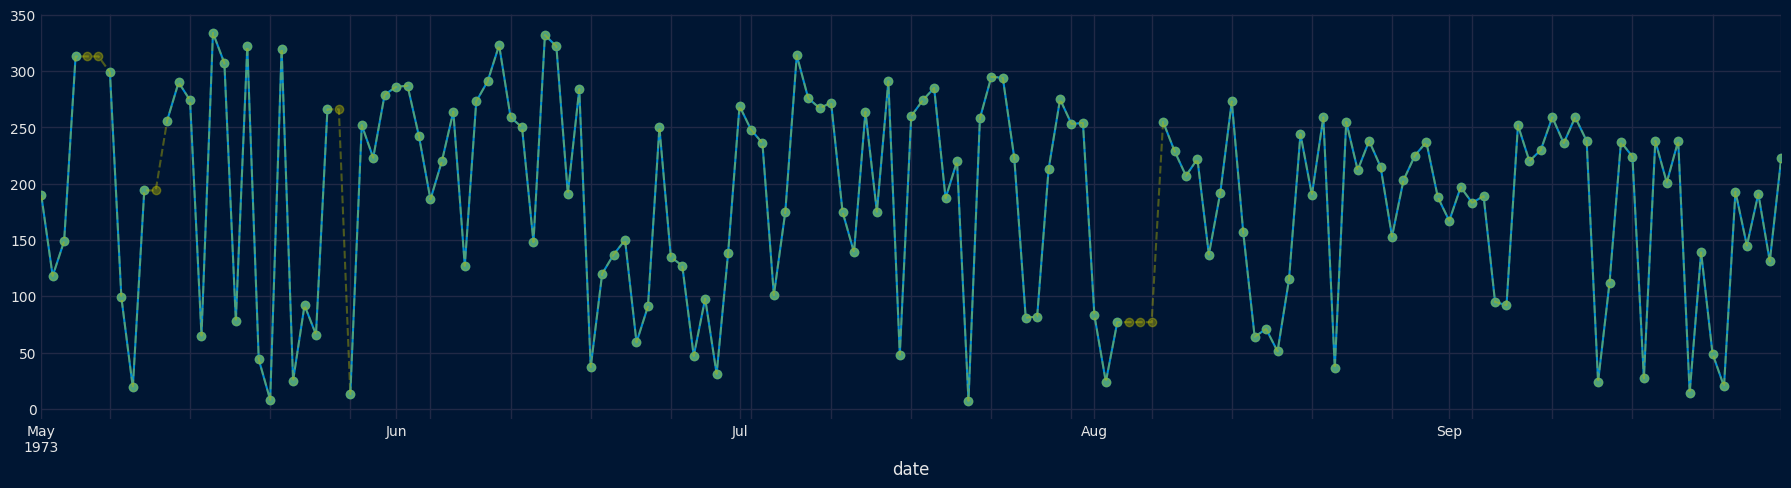

In [15]:
# Imputacion por llenado hacia adelante - Forward fill
plt.figure(figsize=(20,5))
df_serie['Solar.R'].plot(marker='o')
df_serie['Solar.R'].ffill().plot(color = 'y', alpha = 0.4, ls = 'dashed', marker = 'o')
plt.show()

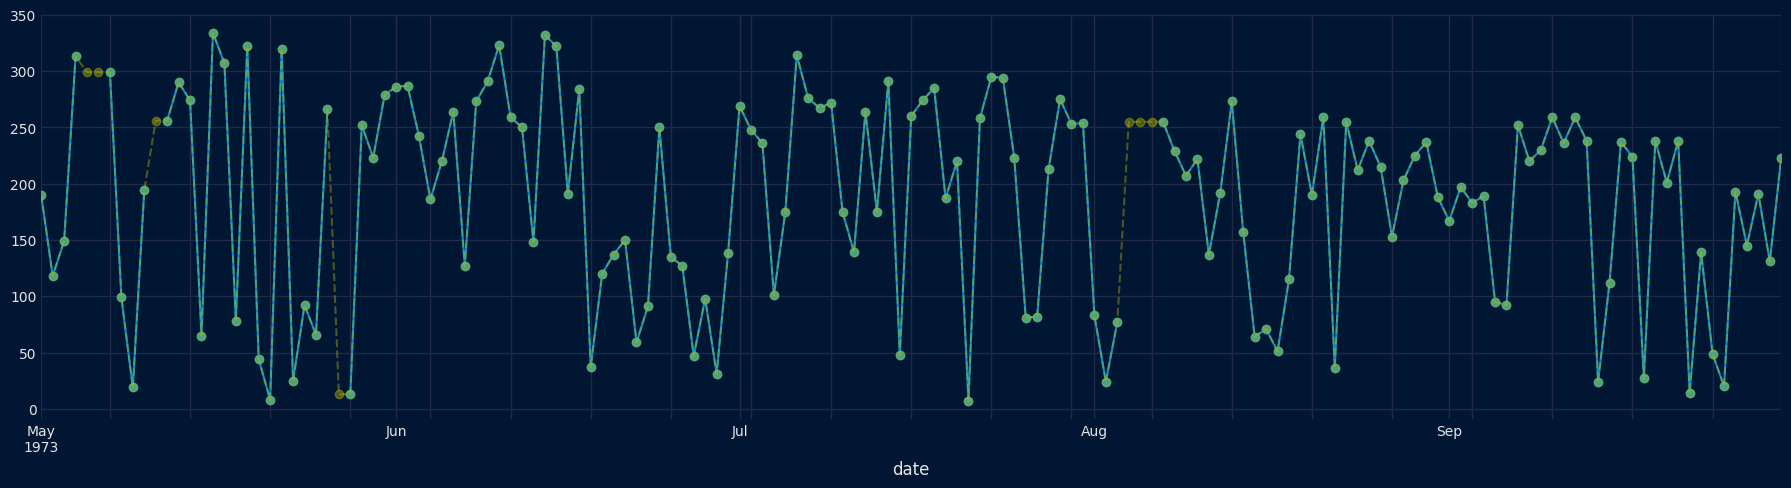

In [16]:
# Imputacion por llenado hacia atras - Backguar fill - Para series economicoas (precio del mercado los fines de semana)
plt.figure(figsize=(20,5))
df_serie['Solar.R'].plot(marker='o')
df_serie['Solar.R'].bfill().plot(color = 'y', alpha = 0.4, ls = 'dashed', marker = 'o')
plt.show()

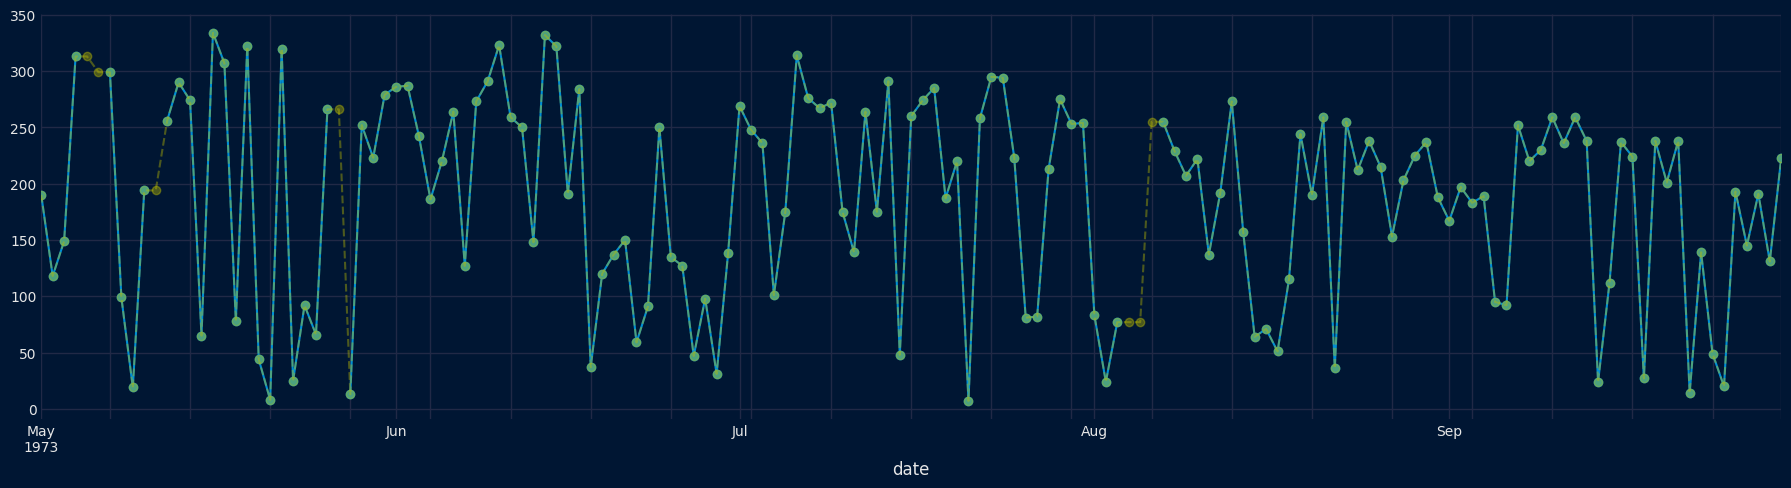

In [17]:
# Imputacion por interpolacion por cercania (imputa con el punto mas cercano)
plt.figure(figsize=(20,5))
df_serie['Solar.R'].plot(marker='o')
df_serie['Solar.R'].interpolate(method = 'nearest').plot(color = 'y', alpha = 0.4, ls = 'dashed', marker = 'o')
plt.show()

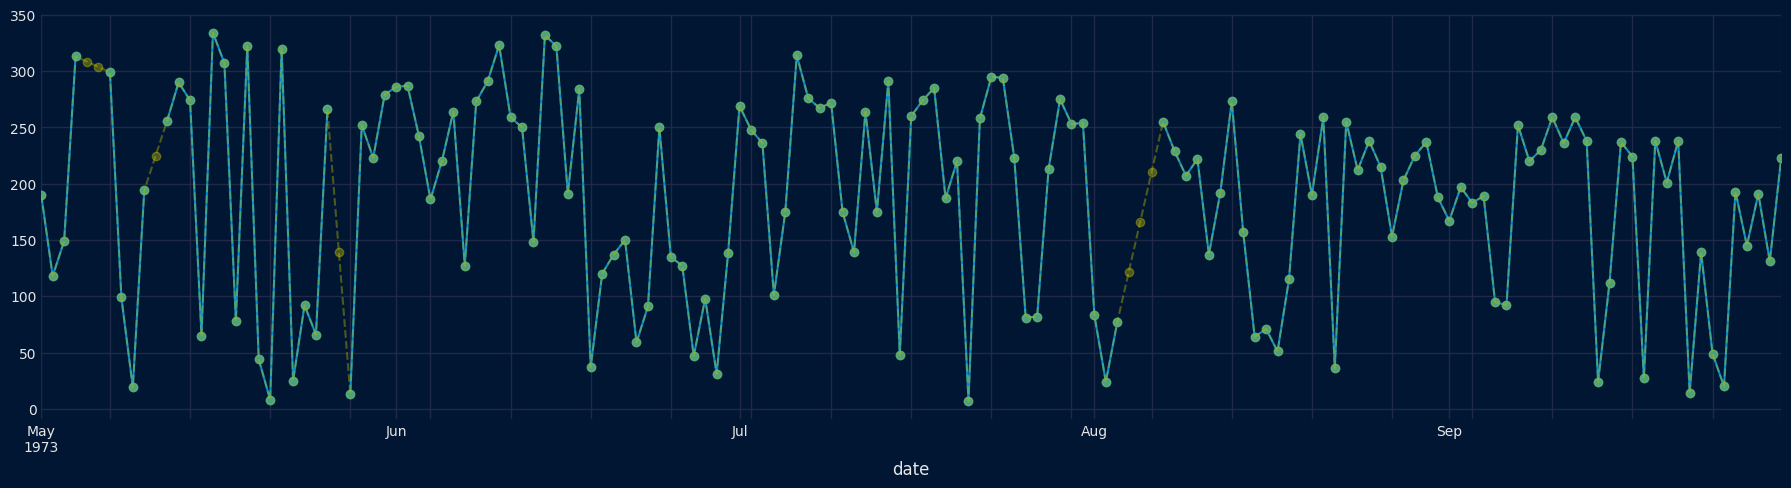

In [18]:
# Imputacion por interpolacion lineal - Linea recta entre dos puntos
plt.figure(figsize=(20,5))
df_serie['Solar.R'].plot(marker='o')
df_serie['Solar.R'].interpolate(method = 'linear').plot(color = 'y', alpha = 0.4, ls = 'dashed', marker = 'o')
plt.show()

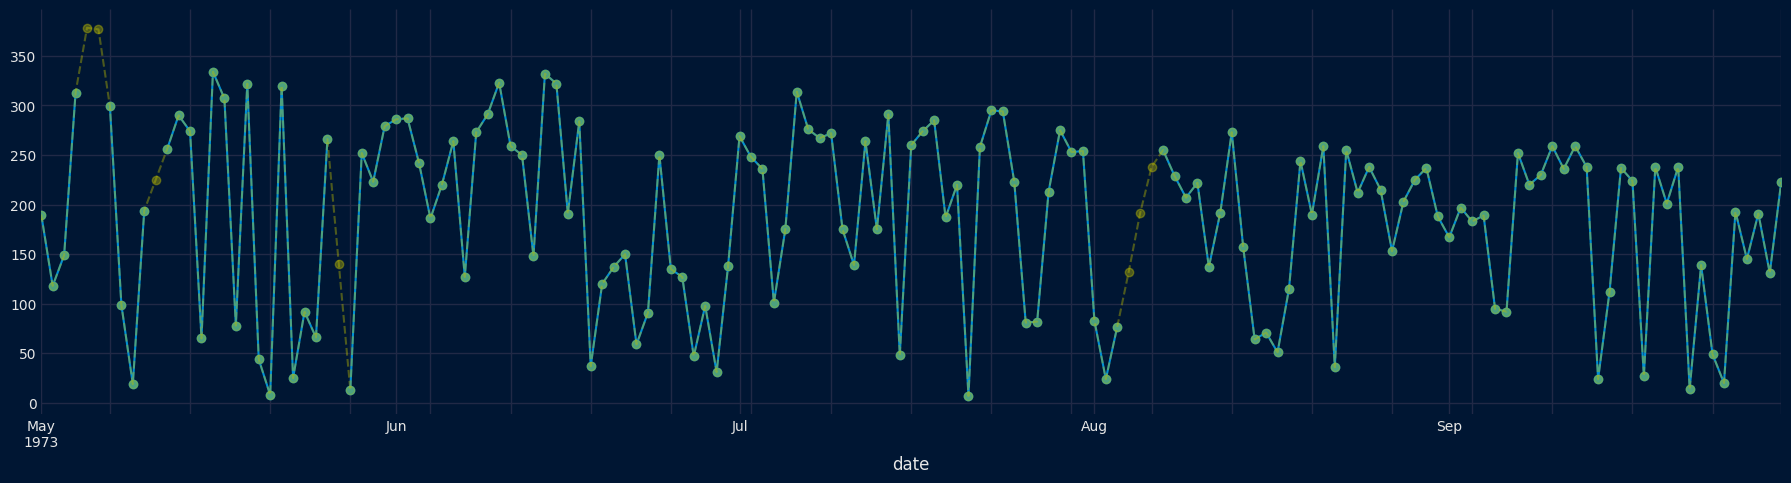

In [19]:
# Imputacion por interpolacion de orden superior suaviazadas ***Es la mejor
plt.figure(figsize=(20,5))
df_serie['Solar.R'].plot(marker='o')
df_serie['Solar.R'].interpolate(method = 'akima').plot(color = 'y', alpha = 0.4, ls = 'dashed', marker = 'o')
plt.show()

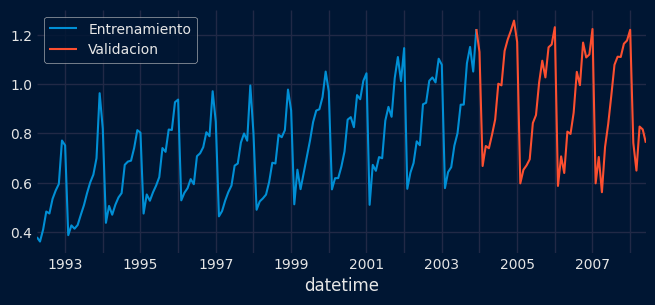

In [20]:
# Separar en entrenamiento y prueba (en series de tiempo no puede ser aleatorio, 70% mas antiguos para train y 30% mas recientes para test)
end_train = '2003-12-01'
data_train = data['y'].loc[:end_train]
data_test = data['y'].loc[end_train:]
plt.figure(figsize = (7, 3))
data_train.plot(label = 'Entrenamiento')
data_test.plot(label = 'Validacion')
plt.legend()
plt.show()

# 7. Modelado

- SARIMAX
- Forecaster
- RNA Secuencial

In [21]:
# Sarimax
from statsmodels.tsa.statespace.sarimax import SARIMAX
modelo_sarimax = SARIMAX(endog = data_train, order = (0,1,0), seasonal_order=(2,1,1,12))
modelo_sarimax = modelo_sarimax.fit(disp = 0)
modelo_sarimax.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                    y   No. Observations:                  141
Model:             SARIMAX(0, 1, 0)x(2, 1, [1], 12)   Log Likelihood                 178.682
Date:                              Mon, 20 Oct 2025   AIC                           -349.365
Time:                                      08:31:39   BIC                           -337.957
Sample:                                  04-01-1992   HQIC                          -344.729
                                       - 12-01-2003                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L12       0.4006      0.203      1.973      0.048       0.003       0.799
ar.S.L24      -0.2295      0.132     -1.737      0.082      -0.488       0.029
ma.S.L12      -0.8188      0.260     -3.144      0.002      -1.329      -0.308
sigma2         0.0033      0.000      7.690      0.000       0.002       0.004
===================================================================================
Ljung-Box (L1) (Q):                  35.76   Jarque-Bera (JB):                13.19
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               2.59   Skew:                            -0.46
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.27
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [24]:
pred_sarimax = modelo_sarimax.get_forecast(steps=len(data_test)).predicted_mean
pred_sarimax.name = 'Predicciones SARIMAX'
display(pred_sarimax.head(4))

2004-01-01    1.153839
2004-02-01    0.719835
2004-03-01    0.792602
2004-04-01    0.791235
Freq: MS, Name: Predicciones SARIMAX, dtype: float64

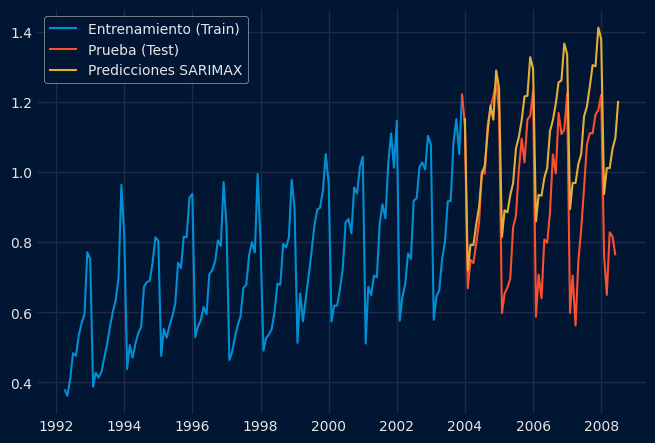

In [25]:
plt.figure(figsize=(7, 5))
plt.plot(data_train, label='Entrenamiento (Train)')
plt.plot(data_test, label='Prueba (Test)')
plt.plot(pred_sarimax, label='Predicciones SARIMAX')
plt.legend()
plt.show()

In [26]:
from sklearn.metrics import mean_absolute_percentage_error
mape_sarimax = mean_absolute_percentage_error(data_test, pred_sarimax)
print(f'MAPE SARIMAX: {mape_sarimax:.4f}')

MAPE SARIMAX: 0.2635


In [29]:
# Forecaster - Series de tiempo con ML
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from skforecast.recursive import ForecasterRecursive
from skforecast.plot import plot_prediction_intervals
from skforecast.preprocessing import RollingFeatures

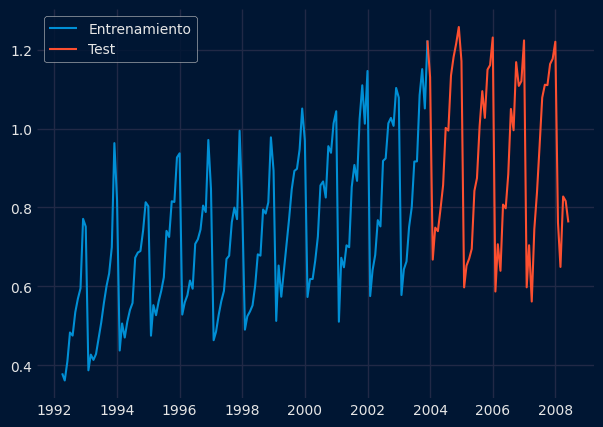

In [28]:
plt.Figure(figsize=(7,3))
plt.plot(data_train, label = "Entrenamiento")
plt.plot(data_test, label = "Test")
plt.legend()
plt.show()

In [31]:
forecaster_1 = ForecasterRecursive(
    regressor = LinearRegression(),
    lags = 15, 
    window_features = RollingFeatures(
        stats=["mean"],
        window_sizes=10
    ))

forecaster_1.fit(y = data_train, store_in_sample_residuals=True)
forecaster_1

=================== 
ForecasterRecursive 
=================== 
Regressor: LinearRegression 
Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15] 
Window features: ['roll_mean_10'] 
Window size: 15 
Series name: y 
Exogenous included: False 
Exogenous names: None 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [Timestamp('1992-04-01 00:00:00'), Timestamp('2003-12-01 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: MS 
Regressor parameters: 
    {'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False} 
fit_kwargs: {} 
Creation date: 2025-10-20 08:55:37 
Last fit date: 2025-10-20 08:55:37 
Skforecast version: 0.18.0 
Python version: 3.13.7 
Forecaster id: None

In [32]:
predictions_1 = forecaster_1.predict(steps=len(data_test))
predictions_1

2004-01-01    1.111554
2004-02-01    0.639690
2004-03-01    0.689112
2004-04-01    0.698062
2004-05-01    0.786592
2004-06-01    0.852667
2004-07-01    0.944152
2004-08-01    0.962054
2004-09-01    1.135455
2004-10-01    1.180984
2004-11-01    1.093922
2004-12-01    1.240321
2005-01-01    1.106812
2005-02-01    0.665317
2005-03-01    0.690337
2005-04-01    0.705423
2005-05-01    0.798573
2005-06-01    0.878663
2005-07-01    0.956437
2005-08-01    0.991798
2005-09-01    1.170185
2005-10-01    1.201430
2005-11-01    1.124880
2005-12-01    1.246809
2006-01-01    1.095354
2006-02-01    0.681203
2006-03-01    0.686018
2006-04-01    0.706667
2006-05-01    0.806932
2006-06-01    0.898985
2006-07-01    0.967262
2006-08-01    1.019203
2006-09-01    1.200567
2006-10-01    1.220776
2006-11-01    1.151890
2006-12-01    1.249643
2007-01-01    1.082657
2007-02-01    0.692560
2007-03-01    0.680140
2007-04-01    0.705687
2007-05-01    0.814464
2007-06-01    0.916657
2007-07-01    0.978775
2007-08-01 

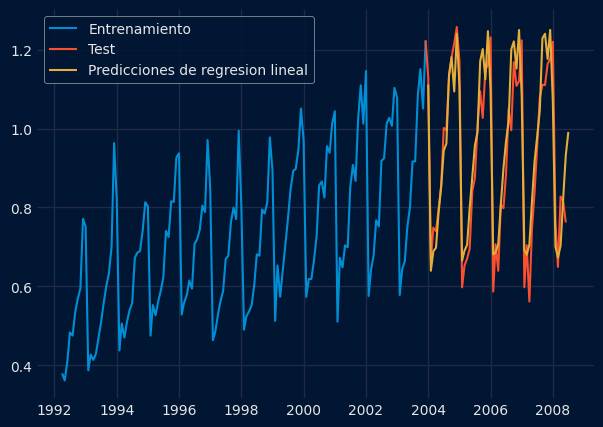

In [35]:
plt.Figure(figsize=(7,3))
plt.plot(data_train, label = "Entrenamiento")
plt.plot(data_test, label = "Test")
plt.plot(predictions_1, label = "Predicciones de regresion lineal")
plt.legend()
plt.show()

In [36]:
mean_absolute_percentage_error(data_test, predictions_1)

0.1483809619028495

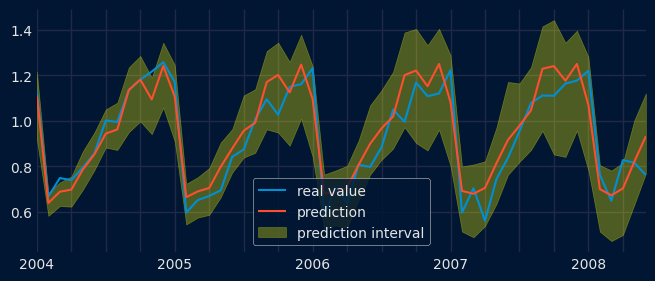

In [38]:
predictions_1_interval = forecaster_1.predict_interval(
    steps = len(data_test) -1,
    interval = [5, 95],
    method = 'bootstrapping', 
    n_boot = 100
)

plot_prediction_intervals(
    predictions = predictions_1_interval,
    y_true = data_test,
    target_variable = 'y',
    kwargs_fill_between = {'color':'yellow', 'alpha':0.3}
)

plt.show()

In [39]:
forecaster_2 = ForecasterRecursive(
    regressor = DecisionTreeRegressor(random_state = 42),
    lags = 15, 
    window_features = RollingFeatures(
        stats=["mean"],
        window_sizes=10
    ))

forecaster_2.fit(y = data_train, store_in_sample_residuals=True)
forecaster_2

=================== 
ForecasterRecursive 
=================== 
Regressor: DecisionTreeRegressor 
Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15] 
Window features: ['roll_mean_10'] 
Window size: 15 
Series name: y 
Exogenous included: False 
Exogenous names: None 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [Timestamp('1992-04-01 00:00:00'), Timestamp('2003-12-01 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: MS 
Regressor parameters: 
    {'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None,
    'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0,
    'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf':
    0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'} 
fit_kwargs: {} 
Creation date: 2025-10-20 09:11:59 
Last fit date: 2025-10-20 09:11:59 
Skforecast version: 0.18.0 
Python version: 3.13.7 
Forecaster id: None

In [41]:
predictions_2 = forecaster_2.predict(steps=len(data_test))
predictions_2

2004-01-01    1.078145
2004-02-01    0.618996
2004-03-01    0.726520
2004-04-01    0.719502
2004-05-01    0.800746
2004-06-01    0.855865
2004-07-01    0.916361
2004-08-01    0.897900
2004-09-01    1.084659
2004-10-01    1.150648
2004-11-01    1.078145
2004-12-01    1.145868
2005-01-01    1.078145
2005-02-01    0.846186
2005-03-01    0.744324
2005-04-01    0.744324
2005-05-01    0.994389
2005-06-01    0.924368
2005-07-01    1.084659
2005-08-01    1.013198
2005-09-01    1.078145
2005-10-01    1.078145
2005-11-01    1.078145
2005-12-01    1.078145
2006-01-01    1.078145
2006-02-01    1.013198
2006-03-01    1.013198
2006-04-01    1.013198
2006-05-01    1.078145
2006-06-01    1.078145
2006-07-01    1.078145
2006-08-01    1.078145
2006-09-01    1.078145
2006-10-01    1.078145
2006-11-01    1.078145
2006-12-01    1.078145
2007-01-01    1.078145
2007-02-01    1.078145
2007-03-01    1.078145
2007-04-01    1.078145
2007-05-01    1.078145
2007-06-01    1.078145
2007-07-01    1.078145
2007-08-01 

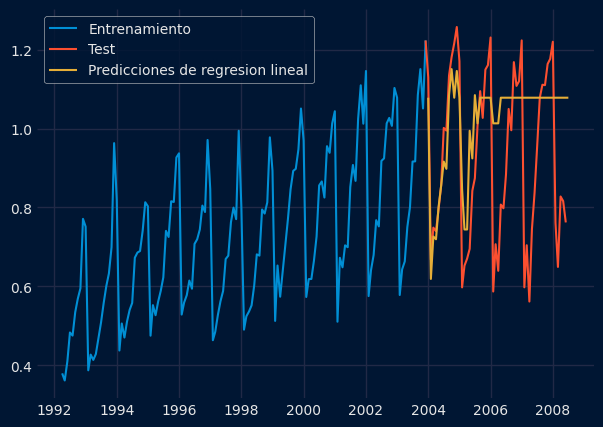

In [42]:
plt.Figure(figsize=(7,3))
plt.plot(data_train, label = "Entrenamiento")
plt.plot(data_test, label = "Test")
plt.plot(predictions_2, label = "Predicciones de regresion lineal")
plt.legend()
plt.show()

Los arboles puros se sobreajustan

In [43]:
mean_absolute_percentage_error(data_test, predictions_2)

0.22674741840245308

In [54]:
from skforecast.model_selection import grid_search_forecaster, random_search_forecaster, TimeSeriesFold
forecaster_2 = ForecasterRecursive(
    regressor = DecisionTreeRegressor(random_state = 42),
    lags = 10
)

# Busqueda de la ventana
lags_grid = {'lags_1':3, 'lags_2':10, 'lags_3':[1,2,3,12]} # Cada 12 periodos hay un evento que se repite

# Busqueda de hiperparametros del regresor
param_grid = {'max_depth':[5, 10, 20], 'criterion':['squared_error', 'poisson', 'absolute_error', 'friedman_mse']}

# Folds
cv = TimeSeriesFold(
    steps = 12,
    initial_train_size = len(data_test),
    refit = False
)

# Implementacion de la busqueda de hiperparametros
result = grid_search_forecaster(
    forecaster = forecaster_2,
    y = data_train,
    param_grid = param_grid,
    lags_grid = lags_grid,
    cv = cv,
    metric = 'mean_squared_error',
    return_best = True,
    n_jobs = 1,
    verbose = False,
    show_progress = True
)

result

lags grid:   0%|          | 0/3 [00:00<?, ?it/s]

params grid:   0%|          | 0/12 [00:00<?, ?it/s]

`Forecaster` refitted using the best-found lags and parameters, and the whole data set: 
  Lags: [ 1  2  3 12] 
  Parameters: {'criterion': 'absolute_error', 'max_depth': 5}
  Backtesting metric: 0.008137813902720652


,lags,lags_label,params,mean_squared_error,criterion,max_depth
0,"[1, 2, 3, 12]",lags_3,"{'criterion': 'absolute_error', 'max_depth': 5}",0.008138,absolute_error,5
1,"[1, 2, 3, 12]",lags_3,"{'criterion': 'absolute_error', 'max_depth': 10}",0.008439,absolute_error,10
2,"[1, 2, 3, 12]",lags_3,"{'criterion': 'absolute_error', 'max_depth': 20}",0.008439,absolute_error,20
3,"[1, 2, 3, 12]",lags_3,"{'criterion': 'friedman_mse', 'max_depth': 10}",0.009701,friedman_mse,10
4,"[1, 2, 3, 12]",lags_3,"{'criterion': 'friedman_mse', 'max_depth': 20}",0.009701,friedman_mse,20
5,"[1, 2, 3, 12]",lags_3,"{'criterion': 'squared_error', 'max_depth': 10}",0.009774,squared_error,10
6,"[1, 2, 3, 12]",lags_3,"{'criterion': 'squared_error', 'max_depth': 20}",0.009774,squared_error,20
7,"[1, 2, 3, 12]",lags_3,"{'criterion': 'squared_error', 'max_depth': 5}",0.009899,squared_error,5
8,"[1, 2, 3, 12]",lags_3,"{'criterion': 'friedman_mse', 'max_depth': 5}",0.009899,friedman_mse,5
9,"[1, 2, 3, 12]",lags_3,"{'criterion': 'poisson', 'max_depth': 5}",0.021059,poisson,5


Validacion cruzada loq ue hace es tomar la ventana de la validacion cruzada e irla

In [55]:
forecaster_2

=================== 
ForecasterRecursive 
=================== 
Regressor: DecisionTreeRegressor 
Lags: [ 1  2  3 12] 
Window features: None 
Window size: 12 
Series name: y 
Exogenous included: False 
Exogenous names: None 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [Timestamp('1992-04-01 00:00:00'), Timestamp('2003-12-01 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: MS 
Regressor parameters: 
    {'ccp_alpha': 0.0, 'criterion': 'absolute_error', 'max_depth': 5,
    'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0,
    'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf':
    0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'} 
fit_kwargs: {} 
Creation date: 2025-10-20 09:39:42 
Last fit date: 2025-10-20 09:39:43 
Skforecast version: 0.18.0 
Python version: 3.13.7 
Forecaster id: None

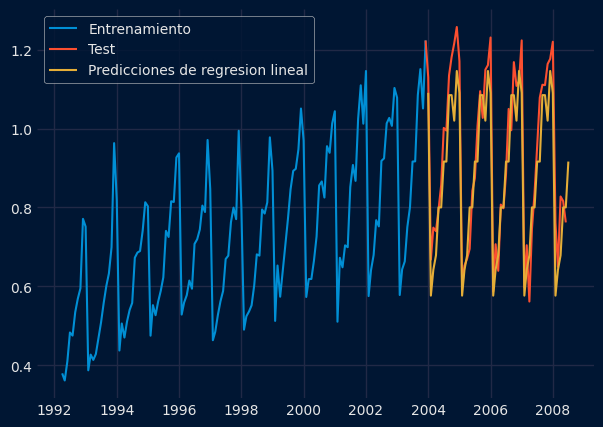

In [57]:
predictions_2 = forecaster_2.predict(steps=len(data_test))
plt.Figure(figsize=(7,3))
plt.plot(data_train, label = "Entrenamiento")
plt.plot(data_test, label = "Test")
plt.plot(predictions_2, label = "Predicciones de regresion lineal")
plt.legend()
plt.show()

In [58]:
from skforecast.model_selection import grid_search_forecaster, random_search_forecaster, TimeSeriesFold
forecaster_3 = ForecasterRecursive(
    regressor = RandomForestRegressor(random_state = 42),
    lags = 10
)

# Busqueda de la ventana
lags_grid = {'lags_1':3, 'lags_2':10, 'lags_3':[1,2,3,12]} # Cada 12 periodos hay un evento que se repite

# Busqueda de hiperparametros del regresor
param_grid = {'max_depth':[5, 10, 20], 'criterion':['squared_error', 'poisson', 'absolute_error', 'friedman_mse']}

# Folds
cv = TimeSeriesFold(
    steps = 12,
    initial_train_size = len(data_test),
    refit = False
)

# Implementacion de la busqueda de hiperparametros
result = grid_search_forecaster(
    forecaster = forecaster_3,
    y = data_train,
    param_grid = param_grid,
    lags_grid = lags_grid,
    cv = cv,
    metric = 'mean_squared_error',
    return_best = True,
    n_jobs = 1,
    verbose = False,
    show_progress = True
)

result

lags grid:   0%|          | 0/3 [00:00<?, ?it/s]

params grid:   0%|          | 0/12 [00:00<?, ?it/s]

`Forecaster` refitted using the best-found lags and parameters, and the whole data set: 
  Lags: [ 1  2  3 12] 
  Parameters: {'criterion': 'squared_error', 'max_depth': 5}
  Backtesting metric: 0.011898283156282243


,lags,lags_label,params,mean_squared_error,criterion,max_depth
0,"[1, 2, 3, 12]",lags_3,"{'criterion': 'squared_error', 'max_depth': 5}",0.011898,squared_error,5
1,"[1, 2, 3, 12]",lags_3,"{'criterion': 'poisson', 'max_depth': 5}",0.012169,poisson,5
2,"[1, 2, 3, 12]",lags_3,"{'criterion': 'friedman_mse', 'max_depth': 5}",0.012217,friedman_mse,5
3,"[1, 2, 3, 12]",lags_3,"{'criterion': 'friedman_mse', 'max_depth': 10}",0.012276,friedman_mse,10
4,"[1, 2, 3, 12]",lags_3,"{'criterion': 'friedman_mse', 'max_depth': 20}",0.012276,friedman_mse,20
5,"[1, 2, 3, 12]",lags_3,"{'criterion': 'squared_error', 'max_depth': 10}",0.012333,squared_error,10
6,"[1, 2, 3, 12]",lags_3,"{'criterion': 'squared_error', 'max_depth': 20}",0.012333,squared_error,20
7,"[1, 2, 3, 12]",lags_3,"{'criterion': 'poisson', 'max_depth': 10}",0.012352,poisson,10
8,"[1, 2, 3, 12]",lags_3,"{'criterion': 'poisson', 'max_depth': 20}",0.012352,poisson,20
9,"[1, 2, 3, 12]",lags_3,"{'criterion': 'absolute_error', 'max_depth': 5}",0.012725,absolute_error,5


In [59]:
forecaster_3

=================== 
ForecasterRecursive 
=================== 
Regressor: RandomForestRegressor 
Lags: [ 1  2  3 12] 
Window features: None 
Window size: 12 
Series name: y 
Exogenous included: False 
Exogenous names: None 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [Timestamp('1992-04-01 00:00:00'), Timestamp('2003-12-01 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: MS 
Regressor parameters: 
    {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth':
    5, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None,
    'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2,
    'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100,
    'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0,
    'warm_start': False} 
fit_kwargs: {} 
Creation date: 2025-10-20 09:45:15 
Last fit date: 2025-10-20 09:45:31 
Skforecast version: 0.18.0 
Python version: 3.13.7 
Forecaster id: None

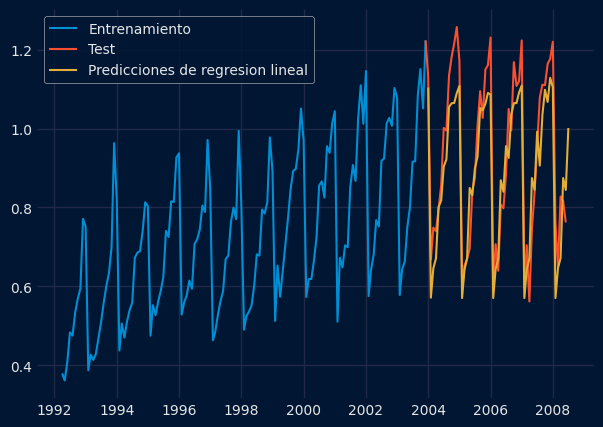

In [60]:
predictions_3 = forecaster_3.predict(steps=len(data_test))
plt.Figure(figsize=(7,3))
plt.plot(data_train, label = "Entrenamiento")
plt.plot(data_test, label = "Test")
plt.plot(predictions_3, label = "Predicciones de regresion lineal")
plt.legend()
plt.show()

In [61]:
mean_absolute_percentage_error(data_test, predictions_3)

0.13219829139884562

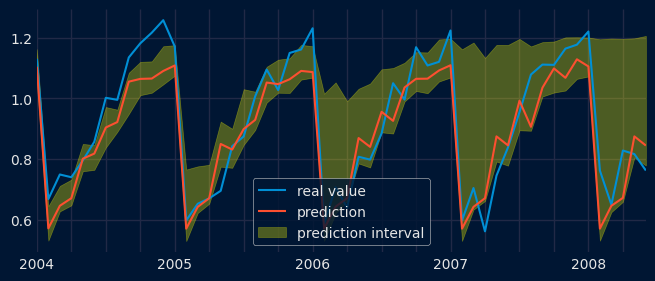

In [62]:
predictions_3_interval = forecaster_3.predict_interval(
    steps = len(data_test) -1,
    interval = [5, 95],
    method = 'bootstrapping', 
    n_boot = 100
)

plot_prediction_intervals(
    predictions = predictions_3_interval,
    y_true = data_test,
    target_variable = 'y',
    kwargs_fill_between = {'color':'yellow', 'alpha':0.3}
)

plt.show()